# 미션 08 (2026.03.09 최신판)
## Football (Semantic Segmentation)
U-Net을 이용해 축구 경기 영상 내의 다양한 객체(예: 골대, 심판, 선수, 관중 등)를 픽셀 단위로 분할하는 Semantic Segmentation 작업을 수행합니다

11개 클래스
- Goal Bar (골대)
- Referee (심판)
- Advertisement (광고판)
- Ground (잔디)
- Ball (축구공)
- Coaches & Officials (코칭 스태프 및 심판진)
- Audience (관중)
- Goalkeeper A (팀 A 골키퍼)
- Goalkeeper B (팀 B 골키퍼)
- Team A (팀 A 선수)
- Team B (팀 B 선수)

미션 16을 위해서 QAT 경량화도 함께 모델 학습시 진행하도록 하겠습니다.

conda 서버 생성 및 설치
```bash
conda create -n part2 python=3.10
conda activate part2

conda install pytorch torchvision pytorch-cuda=11.8 -c pytorch -c nvidia
pip install opencv-python matplotlib albumentations segmentation-models-pytorch
pip install ipykernel
```

In [1]:
# 기본
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import json

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2  # ← 기존 코드에 없었는데 필요

# ResNet50 백본 U-Net
import segmentation_models_pytorch as smp

d:\jupyter\Anaconda\install\envs\part2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("sadhliroomyprime/football-semantic-segmentation")

# print("Path to dataset files:", path)

In [2]:
print("Current working dir:", os.getcwd())
print("Notebook file (approx):", Path().resolve())   # 보통 커널의 CWD
print("Listing CWD files:", os.listdir('.'))

zip_file_path = './archive.zip'
print("zip_file_path (given):", zip_file_path)
print("absolute path ->", os.path.abspath(zip_file_path))
print("exists?", os.path.exists(zip_file_path))
print("is file?", os.path.isfile(zip_file_path))

Current working dir: d:\02.study\part4_wj\misson\mission16
Notebook file (approx): D:\02.study\part4_wj\misson\mission16
Listing CWD files: ['.claude', 'data', 'Mission16_Lightweight_Quantization_Guide.md', 'notebook_analysis.md', 'notebook_code.txt', 'Segmentation_Improvement_Guide.md', '기존 모델.ipynb']
zip_file_path (given): ./archive.zip
absolute path -> d:\02.study\part4_wj\misson\mission16\archive.zip
exists? False
is file? False


In [3]:
# ============================================
# 압축 파일 풀기
# ============================================

# 압축할 zip 파일 경로
zip_file_path = './archive.zip'
# 압축 풀고 싶은 디렉토리 경로
extract_path = './data/'

# 이미 압축이 있다면 건너뛰기
if os.path.exists(extract_path) and os.listdir(extract_path):
    print(f"'{extract_path}'에 이미 파일이 있습니다. 압축 풀기를 건너뜁니다.")
else:
    # extract_path 디렉토리가 없으면 생성
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    # zip 파일 열기
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # 지정한 경로에 모든 파일 압축 풀기
        zip_ref.extractall(extract_path)
        print(f"'{zip_file_path}' 파일이 '{extract_path}'에 성공적으로 풀렸습니다.")

'./data/'에 이미 파일이 있습니다. 압축 풀기를 건너뜁니다.


### 전체 흐름 요약

1. 데이터 준비 – 폴더 안의 이미지와 마스크를 매칭해 image_pairs 리스트에 저장합니다.
2. 시각화 – 몇 개의 원본·마스크 쌍을 화면에 띄워 데이터가 올바르게 매칭됐는지 확인합니다.
3. 클래스 매핑 – 마스크에 쓰인 고유 RGB 색상을 수집해 color_to_label 딕셔너리를 만듭니다.
4. Dataset 정의 – FootballDataset 클래스에서 이미지·마스크를 읽어 정규화하고, RGB 마스크를 정수 클래스 인덱스로 변환합니다.
5. DataLoader – 학습·검증용 데이터 로더를 생성합니다.
6. 모델 정의 – U‑Net 구조를 UNet 클래스에 구현합니다.
7. 학습 루프 – Cross‑Entropy 로스를 계산해 가중치를 업데이트합니다.
8. 검증 및 시각화 – 테스트 세트에서 예측한 마스크를 원본 이미지와 정답 마스크와 함께 화면에 표시합니다.

아래에서 각 단계별 핵심 코드를 한 줄씩 짚어 보겠습니다.

## 1. 모든 함수/클래스 정의

In [4]:
# ============================================
# 데이터셋 전체의 고유한 색상 수집
# ============================================

def get_unique_colors(image_folder, mask_files, max_classes=11, ignore_color=None, verbose=False):
    """
    마스크 이미지에서 사용된 고유 RGB 색을 추출하고, (R,G,B) 튜플 목록을 반환한다.

    Args:
        image_folder (str): 마스크 파일이 들어있는 파일 경로
        mask_files (str) : 마스크 파일명 리스트 (예. Frame 1  (4).jpg___fuse.png)
        max_classes (int, optional): _description_. Defaults to 11.
        ignore_color (List[Tuple[int,int,int]]) : 무시할 색 (예. 배경색) 지정하면 해당 색은 집합에 추가되지 않는다.
        verbose (bool) : 진행 상황을 콘솔에 출력

    Returns:
        List[Tuple[int,int,int]]
            정렬된 고유 색 목록. (R,G,B) 형태 튜플이며,
            (R,G,B) 순서로 정렬되어 매 실행마다 동일한 순서를 보장한다.
    """
    # 초기 설정
    ignore_set = set(ignore_color or [])
    color_set = set()
    
    # 파일 순회
    for i, mask_file in enumerate(mask_files):
        mask_path = os.path.join(image_folder, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        
        if mask is None:
            raise FileNotFoundError(f'[get_unique_colors] 마스크를 읽을 수 없습니다.: {mask_path}')
        
        # BGR -> RGB
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # 고유 색 추출
        unique_colors = np.unique(mask.reshape(-1, 3), axis=0)
        
        # 색을 집합에 추가 (ignore 색 제외)
        for color in unique_colors:
            color_tuple = tuple(int(c) for c in color) # numpy scalar -> 파이썬 int
            if color_tuple in ignore_set:
                continue
            color_set.add(color_tuple)  # 고유한 색상 저장
            
        if verbose and (i + 1) % 100 == 0:
            print(f"[get_unique_colors] {i+1}/{len(mask_files)} 파일 처리 → 현재 색 개수: {len(color_set)}")

        # 클래스 개수가 max_classes개가 되면 중단
        if len(color_set) >= max_classes:
            if verbose:
                print(f"[get_unique_colors] {max_classes}개의 고유 색을 찾았으므로 탐색 종료 (파일 #{i+1}/{len(mask_files)})")
                break
    
    # 정렬 & 반환 (R->G->B 순서로 Deterministic 정렬)           
    sorted_colors = sorted(color_set, key=lambda c: (c[0], c[1], c[2]))
    if verbose:
        print(f"[get_unique_colors] 최종 고유 색 개수: {len(sorted_colors)} (예시: {sorted_colors[:5]})")
    return sorted_colors

In [5]:
# ============================================
# 데이터 파일 로딩 & 매칭
# ============================================

# 폴더 내 모든 파일 목록 가져오기
image_folder = os.path.join(extract_path, "images")
file_list = os.listdir(image_folder)

# 원본 이미지(.jpg)와 fuse 이미지 매칭
original_files = sorted([f for f in file_list if f.endswith(".jpg")])
fuse_files = sorted([f for f in file_list if "fuse" in f])

# 이미지 로드 및 확인
image_pairs = []
for orig_file in original_files:
    # 동일한 프레임의 fuse 파일 찾기
    base_name = orig_file.replace(".jpg", "")
    fuse_file = next((f for f in fuse_files if base_name in f), None)

    if fuse_file:
        # 원본과 마스크 로드
        img_path = os.path.join(image_folder, orig_file)
        mask_path = os.path.join(image_folder, fuse_file)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if img is not None and mask is not None:
            image_pairs.append((img, mask))

# 최종적으로 로드된 이미지 쌍 개수 출력
print(f"{len(image_pairs)} pairs")

100 pairs


In [6]:
# ============================================
# 색상 매핑 JSON 저장 / 로드 함수
# ============================================

def save_color_mapping(color_to_label, filepath='color_mapping.json'):
    """
    color_to_label 을 JSON 파일로 저장

    Args:
        color_to_label (dict): {(R,G,B): label_idx} 매핑
        filepath (str): 저장할 JSON 파일 경로
    """
    
    # 튜플 키를 문자열로 변환 (JSON 은 튜플 키를 지원하지 않음)
    color_to_label_str = {str(color): label for color, label in color_to_label.items()}
    
    with open(filepath, 'w') as f:
        json.dump(color_to_label_str, f, indent=2)
    print(f"색상 매핑이 '{filepath}'에 저장되었습니다.")

def load_color_mapping(filepath='color_mapping.json'):
    """
    JSON 에서 color_to_label 을 불러옴
    
    Args:
        dict: {(R,G,B): label_idx} 매핑
    """
    with open(filepath,'r') as f:
        color_to_label_str = json.load(f)
        
    # 문자열 키를 다시 튜플로 변환
    # "(255, 0, 0)" -> (255, 0, 0)
    color_to_label = {}
    for color_str, label in color_to_label_str.items():
        # 문자열을 튜플로 변환
        color_tuple = eval(color_str) # "(255, 0, 0)" -> (255, 0, 0)
        color_to_label[color_tuple] = label
        
    print(f"'{filepath}'에서 {len(color_to_label)}개의 색상 매핑을 불러왔습니다.")
    return color_to_label

def get_or_create_color_mapping(image_folder, fuse_files,
                                filepath='color_mapping.json',
                                max_classes=11,
                                ignore_color=None,
                                force_create=False):
    """
    JSON 파일이 있으면 불러오고, 없으면 생성해서 저장

    Args:
        image_folder (str): 이미지 폴더 경로
        fuse_files (list): 마스크 파일 리스트
        filepath (str): JSON 파일 경로
        max_classes (int): 최대 클래스 수
        ignore_color (list): 무시할 색상
        force_create (bool): True면 기존 파일 무시하고 새로 생성
        
    Returns:
        dict : {(R,G,B): label_idx} 매핑
    """
    
    # 파일이 존재하고 force_create 가 False 이면 불러오기
    if os.path.exists(filepath) and not force_create:
        print(f"기존 색상 매핑 파일 발견 : '{filepath}'")
        color_to_label = load_color_mapping(filepath)
        return color_to_label
    
    # 파일이 없거나 force_create=True 면 새로 생성
    print("색상 매핑 파일이 없습니다. 새로 생성합니다...")
    print("(이 작업은 시간이 걸릴 수 있습니다)")
    unique_colors = get_unique_colors(
        image_folder, fuse_files,
        max_classes=max_classes,
        ignore_color = ignore_color,
        verbose=True)
    
    color_to_label = {color : idx for idx, color in enumerate(unique_colors)}
    
    # JSON 으로 저장
    save_color_mapping(color_to_label, filepath)
    
    return color_to_label

### U-Net 세그멘테이션 데이터 증강(Augmentation)
시맨틱 세그멘테이션 모델인 U-Net을 학습할 때도 데이터 증강은 적극적으로 권장됩니다.

증강이 필요한 이유
- **일반화 능력 향상** : 모델이 다양한 환경(각도, 크기, 위치) 의 객체를 인식하도록 훈련하는 **오버피팅(Overfitting)을 방지** 하고 실제 환경에서의 성능을 높입니다.
- **데이터 부족 해소** : 세그멘테이션 데이터셋은 구축이 어렵고 양이 적은 경우가 많습니다. 증강은 사실상 **데이터의 양을 늘리는 효과** 를 가져옵니다.

#### ※ 주의 사항: **이미지와 마스크 동시 적용**

세그멘테이션에서 가장 중요한 점은 원본 이미지와 정답 마스크(Ground Truth Mask)에 동일한 변형을 동시에 적용해야 한다는 것입니다.

`FootballDataset` 클래스에 이를 위한 구조가 마련하였습니다.
```python
# FootballDataset __getitem__ 내부 — albumentations 방식
if self.transform:
    transformed = self.transform(image=img, mask=mask)  # numpy 단계에서 적용
    img  = transformed['image']
    mask = transformed['mask']
```
따라서 `transform` 은 **albumentations**의 `A.Compose` 로 구성하며, 이미지와 마스크를 키워드 인수(`image=`, `mask=`)로 받아 동일한 기하학적 변형을 동시에 적용합니다.

> 주의: transform 적용은 텐서 변환 전 numpy 단계에서 이루어집니다.<br/> 따라서 A.Normalize는 transform에 포함하지 않으며, 정규화는 Dataset 내부에서 별도로 처리합니다.

```python
# transform 선언 예시 (Normalize 제외, 기하학적 증강만)
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
])

val_transform = None  # 검증 시 증강 없음
```

In [7]:
# ============================================
# Dataset 클래스 정의 (RGB 마스크 변환 포함)
# ============================================
    
class FootballDataset(Dataset):
    """
    - 이미지 + RGB 마스크를 로드하고,
    - 사전에 정의된 `color_to_lable` 로 RGB 마스크를 정수 라벨로 변환
    - `transform` 함수를 통해 이미지·마스크 동시 전처리를 지원
    """
    
    def __init__(self,
                 image_files: List[str],
                 mask_files: List[str],
                 image_folder: str,
                 color_to_label: Dict[Tuple[int,int,int], int],
                 transform=None,
                 target_size: Tuple[int,int] = (256, 256),
                 ignore_colors: Optional[List[Tuple[int,int,int]]] = None,
                 verify_mapping: bool = True,
                 mean: Tuple[float,...] = (0.485, 0.456, 0.406),  # (ImageNet 기본값)
                 std: Tuple[float,...]  = (0.229, 0.224, 0.225),  # (ImageNet 기본값)
                 ):
        """
        Args:
            image_files, mask_files (List)
                : 같은 인덱스끼리 짝을 이루는 파일명 리스트
            image_folder (str)
                : 두 리스트에 있는 파일이 모두 들어 있는 디렉터리
            color_to_label (dict)
                : (R,G,B) 튜플 -> 라벨 정수 매핑, 0~N-1 로 연속되어야 함
            transform
                : albumentations Compose (기하학적 증강만 포함, Normalize 제외)
            target_size (W,H)
                : 모든 이미지·마스크를 cv2.resize 로 맞출 크기
            ignore_colors (list of tuple, optional)
                : 라벨링에 쓰지 않을 색. 해당 픽셀은 -1 로 마킹
            verify_mapping (bool)
                : True 면 모든 마스크 색이 color_to_label 혹은 ignore_colors 에
                  포함되는지 검사
            mean (tuple)
                : 정규화 평균값. ResNet50(ImageNet): (0.485, 0.456, 0.406)
                  기본 U-Net: (0.0, 0.0, 0.0) 으로 설정하면 /255 만 적용
            std (tuple)
                : 정규화 표준편차. ResNet50(ImageNet): (0.229, 0.224, 0.225)
                  기본 U-Net: (1.0, 1.0, 1.0) 으로 설정하면 /255 만 적용
        """
        assert len(image_files) == len(mask_files),\
            "이미지 파일 수와 마스크 파일 수가 다릅니다."
        
        # 파일 리스트를 반드시 정렬해 동일 인덱스가 같은 프레일을 가리키게 합니다.
        self.image_files = sorted(image_files)
        self.mask_files  = sorted(mask_files)
        self.image_folder = image_folder
        self.color_to_label = color_to_label
        self.transform = transform
        self.target_w, self.target_h = target_size
        self.ignore_colors = ignore_colors or []
        # ImageNet 정규화 상수를 numpy 배열로 저장
        self.mean = np.array(mean, dtype=np.float32) 
        self.std  = np.array(std,  dtype=np.float32)
        self.LUT = self._create_lut() 
        
        if verify_mapping:
            self._verify_all_colors()
            
    def _create_lut(self) -> np.ndarray:
        """
        색상 매핑 LUT를 한번만 생성

        Returns:
            2^24 크기의 LUT (모든 RGB 조합 커버)
        """
        #  매핑 테이블을 2-D 배열(65536*256) 으로 만든 뒤 색을 라벨 인덱싱
        # (8 bit per channel -> 전체 2**24 개의 경우의 수 이므로 메모리가 허용됨)
        LUT = np.full(2**24, fill_value=-1, dtype=np.int64)  # 기본 -1
        
        # int() 로 명시적 변환하여 오버플로우 방지
        for rgb, lbl in self.color_to_label.items():
            key = (int(rgb[0]) << 16) | (int(rgb[1]) << 8) | int(rgb[2])
            LUT[key] = lbl
            
        for rgb in self.ignore_colors:
            key = (int(rgb[0]) << 16) | (int(rgb[1]) << 8) | int(rgb[2])
            LUT[key] = -1
            
        return LUT
            
    # 클래스 검증 (디버깅용)
    def _verify_all_colors(self):
            """모든 마스크 색상 검증"""
            known_colors = set(self.color_to_label.keys())
            known_colors.update(self.ignore_colors)
            
            for mask_file in self.mask_files:
                mask_path = os.path.join(self.image_folder, mask_file)
                mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
                if mask is None:
                    raise FileNotFoundError(f"Mask 파일 없음: {mask_path}")
                mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
                uniq = np.unique(mask.reshape(-1, 3), axis=0)
                
                for c in uniq:
                    tup = tuple(int(v) for v in c)
                    if tup not in known_colors:
                        raise ValueError(
                            f"mask {mask_file}에 알 수 없는 색 {tup}"
                        )
    
    def __len__(self)->int:
        return len(self.image_files)

    def __getitem__(self, idx:int) -> Tuple[torch.Tensor, torch.Tensor]:
        # 이미지, 마스크 경로
        img_path  = os.path.join(self.image_folder, self.image_files[idx])
        mask_path = os.path.join(self.image_folder, self.mask_files[idx])

        # 원본 이미지 로드 & 전처리
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Image 파일을 찾을 수 없습니다: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.target_w, self.target_h),
                         interpolation=cv2.INTER_LINEAR)
        
        # 마스크 로드
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        if mask is None:
            raise FileNotFoundError(f"Mask 파일을 찾을 수 없습니다: {mask_path}")
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (self.target_w, self.target_h),
                          interpolation=cv2.INTER_NEAREST)
        
        # Albumentations 적용 (기하학적 증강만, Normalize 미포함)
        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img  = transformed['image']
            mask = transformed['mask']
        
        # LUT 기반 RGB → 정수 라벨 변환
        packed = (mask[..., 0].astype(np.uint32) << 16) | \
                 (mask[..., 1].astype(np.uint32) << 8)  | \
                 (mask[..., 2].astype(np.uint32))
        label_mask = self.LUT[packed]

        # (optional) unknown 색(-1) 가 있으면 0(배경) 으로 바꾸거나 에러를 낼 수 있음
        if np.any(label_mask == -1):
            # 여기서는 0(배경) 로 대체. 필요시 raise 로 변경.
            label_mask[label_mask == -1] = 0

        # float32 로 변환 + [0,1] 정규화
        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std
        
        # ----- torch Tensor 로 변환 ----- #
        # 이미지: (H,W, C) → (C, H, W) , float32
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).contiguous()
        # 마스크: (H, W) , int64 (CrossEntropyLoss 가 요구하는 타입)
        mask_tensor = torch.from_numpy(label_mask).long()

        return img_tensor, mask_tensor

## 모델 구조 설명
```
입력 이미지 (3, 256, 256)
    ↓
[Encoder — ResNet50 (ImageNet 사전학습)]
layer0: Conv7x7 + BN + ReLU + MaxPool  →  (64,  64×64)
layer1: ResBlock ×3                    →  (256, 64×64)
layer2: ResBlock ×4                    →  (512, 32×32)
layer3: ResBlock ×6                    →  (1024,16×16)
layer4: ResBlock ×3                    →  (2048, 8×8)
    ↓
[Decoder + Skip Connections — smp 자동 구성]
up1: (2048 → 256) + skip from layer3  →  (256, 16×16)
up2: (256  → 128) + skip from layer2  →  (128, 32×32)
up3: (128  →  64) + skip from layer1  →  (64,  64×64)
up4: (64   →  32) + skip from layer0  →  (32, 128×128)
up5: (32   →  16)                     →  (16, 256×256)
    ↓
[Segmentation Head]
Conv2d(16 → 11, kernel=3) + Upsample
    ↓
출력 (11, 256, 256)
```

> 백본 가중치는 고정(freeze)하지 않고 fine-tuning 방식으로 전체 학습

In [8]:
# ============================================
# ResNet50 백본 U-Net 모델 정의 (smp 활용)
# ============================================
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet50",       # ResNet50 백본
    encoder_weights="imagenet",    # ImageNet 사전학습 가중치
    in_channels=3,                 # RGB 입력
    classes=11,                    # 11개 클래스
    activation=None,               # CrossEntropyLoss 사용 시 None
)


d:\jupyter\Anaconda\install\envs\part2\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\w00sh\.cache\huggingface\hub\models--smp-hub--resnet50.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ResNet 50 백본을 하기 전에 커스텀 U-Net 만들어봤을때

mIoU :  0.4553 <br/>
Pixel Accuracy : 0.8539

수치가 이렇게 나왔습니다.

In [ ]:
# ============================================
# 커스텀 U-Net 모델 정의 (사용안함)
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv2d -> BatchNorm -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling: MaxPool -> DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling: Upsample -> Concat -> DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 
                                     kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # x2의 크기에 맞춰 x1 패딩 (필요시)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                       diffY // 2, diffY - diffY // 2])
        
        # Concatenate
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net 모델
    
    Args:
        n_channels: 입력 이미지 채널 수 (RGB: 3)
        n_classes: 출력 클래스 수 (11개)
    """
    def __init__(self, n_channels=3, n_classes=11):
        super(UNet, self).__init__()
        
        # Encoder (Contracting Path)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        # Decoder (Expanding Path)
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        # Output layer
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)      # 64 channels
        x2 = self.down1(x1)   # 128 channels
        x3 = self.down2(x2)   # 256 channels
        x4 = self.down3(x3)   # 512 channels
        x5 = self.down4(x4)   # 1024 channels
        
        # Decoder (skip connections)
        x = self.up1(x5, x4)  # 512 channels
        x = self.up2(x, x3)   # 256 channels
        x = self.up3(x, x2)   # 128 channels
        x = self.up4(x, x1)   # 64 channels
        
        # Output
        logits = self.outc(x) # n_classes channels
        return logits

## 커스텀 U-Net vs ResNet50 U-Net 비교 회고

### 커스텀 U-Net의 한계

- **랜덤 초기화**: 가중치를 처음부터 학습해야 하므로 100장의 데이터로는 턱없이 부족
- **얕은 특징 추출**: 단순한 Conv+BN+ReLU 반복 구조로 복잡한 패턴(선수 윤곽, 공 등) 인식 한계
- **과적합 위험**: 데이터가 적은데 학습할 파라미터가 많아 일반화 성능 저하

### ResNet50이 더 좋았던 이유

- **ImageNet 사전학습**: 수백만 장 이미지로 이미 학습된 엣지, 텍스처, 형태 특징을 그대로 활용
- **잔차 연결(Residual Connection)**: 깊은 네트워크에서도 기울기 소실 없이 안정적 학습
- **전이학습 효과**: 적은 데이터(100장)로도 빠르게 수렴하고 높은 성능 달성

> 데이터가 적을수록 사전학습 백본의 효과는 더욱 극대화됩니다.

EarlyStopping 을 재사용하기 위해서는

`객체 탐지` 였던 클래스에서 `Semantic Segmentation` 으로 바꾸어야 합니다.


#### 주요 차이점

| 항목 | 객체 탐지 (Object Detection) | 시맨틱 분할 (Semantic Segmentation) |
| :--- | :--- | :--- |
| **Task** | Bounding Box 예측 | 픽셀별 클래스 예측 |
| **출력** | `[{boxes, labels, scores}]` | `(B, C, H, W)` logits (픽셀별 클래스 확률) |
| **Loss** | Faster R-CNN 내장 Loss | `Cross Entropy Loss` |
| **평가** | mAP (IoU 기반) | Pixel Accuracy, mIoU, Dice |
| **입력** | 이미지 리스트 + 타겟 딕셔너리 | 이미지 텐서 + 마스크 텐서 |

In [9]:
# ============================================
# 학습 함수 (Semantic Segmentation용)
# ============================================

from tqdm import tqdm
import time

class EarlyStopping:
    """Early Stopping (mIoU기반)"""
    def __init__(self, patience=5, verbose=True, delta=0.0, path="best_model.pt"):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.path = path
        
    def __call__(self, val_miou, model):
        score = val_miou
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"Early Stopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
        
        return self.early_stop
    
    def save_checkpoint(self, model):
        if self.verbose:
            print(f"Validation mIoU increased ({self.best_score:.4f}). Saving model...")
        torch.save(model.state_dict(), self.path)

In [10]:
def calculate_metrics(pred, target, num_classes):
    """
    Pixel Accuracy, mIoU, Dice Score 계산
    
    Args:
        pred: (B, H, W) - 예측 클래스 인덱스
        target: (B, H, W) - 실제 클래스 인덱스
        num_classes: 클래스 개수
    
    Returns:
        dict: {'pixel_acc', 'miou', 'dice', 'class_ious'}
    """
    
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()
    
    # Pixel Accuracy
    correct = (pred == target).sum()
    total = target.size
    pixel_acc = correct / total
    
    # IoU per class
    ious = []
    class_ious = {}
    
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        
        if union == 0:
            iou = float('nan')  # 해당 클래스가 없음
        else:
            iou = intersection / union
        
        class_ious[f'class_{cls}'] = iou
        if not np.isnan(iou):
            ious.append(iou)
    
    # mIoU (평균 IoU)
    miou = np.mean(ious) if len(ious) > 0 else 0.0
    
    # Dice Score (F1-Score와 동일)
    dice_scores = []
    for cls in range(num_classes):
        pred_cls  = (pred == cls)
        target_cls = (target == cls)
        intersection = (pred_cls & target_cls).sum()
        denom = pred_cls.sum() + target_cls.sum()
        if denom == 0:
            continue
        dice_scores.append(2 * intersection / denom)

    dice = np.mean(dice_scores) if dice_scores else 0.0

    
    return {
        'pixel_acc': pixel_acc,
        'miou': miou,
        'dice': dice,
        'class_ious': class_ious
    }
    
    
def train_epoch(model, train_loader, criterion, optimizer, device, num_classes):
    """한 에포크 학습"""
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for images, masks in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward
        outputs = model(images)  # (B, C, H, W)
        loss = criterion(outputs, masks)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # 예측 (배치별로 저장)
        preds = torch.argmax(outputs, dim=1)  # (B, H, W)
        all_preds.append(preds.detach())
        all_targets.append(masks)
    
    # 전체 배치 합치기
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    # 메트릭 계산
    metrics = calculate_metrics(all_preds, all_targets, num_classes)
    avg_loss = total_loss / len(train_loader)
    
    return avg_loss, metrics
        
        
def validate_epoch(model, val_loader, criterion, device, num_classes):
    """검증"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds)
            all_targets.append(masks)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    metrics = calculate_metrics(all_preds, all_targets, num_classes)
    avg_loss = total_loss / len(val_loader)
    
    return avg_loss, metrics

def train_model(model, train_loader, val_loader, num_classes, device,
                num_epochs=50, lr=0.001, patience=7, model_name='unet', class_weights=None):
    """
    전체 학습 파이프라인
    
    Args:
        model: U-Net 모델
        train_loader, val_loader: DataLoader
        num_classes: 클래스 개수
        device: cuda/cpu
        num_epochs: 최대 에포크 수
        lr: 학습률
        patience: Early Stopping patience
        model_name: 모델 저장 이름
    
    Returns:
        model: 학습된 모델
        history: 학습 히스토리
    """
    # Loss & Optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )
    
    # Early Stopping
    early_stopper = EarlyStopping(
        patience=patience,
        verbose=True,
        path=f'{model_name}_best.pt'
    )
    
    # History
    history = {
        'train_loss': [],
        'train_miou': [],
        'train_pixel_acc': [],
        'val_loss': [],
        'val_miou': [],
        'val_pixel_acc': []
    }
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"{'='*60}")
        
        # Train
        train_loss, train_metrics = train_epoch(
            model, train_loader, criterion, optimizer, device, num_classes
        )
        
        # Validation
        val_loss, val_metrics = validate_epoch(
            model, val_loader, criterion, device, num_classes
        )
        
        # 히스토리 저장
        history['train_loss'].append(train_loss)
        history['train_miou'].append(train_metrics['miou'])
        history['train_pixel_acc'].append(train_metrics['pixel_acc'])
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_metrics['miou'])
        history['val_pixel_acc'].append(val_metrics['pixel_acc'])
        
        # 결과 출력
        print(f"Train Loss: {train_loss:.4f} | mIoU: {train_metrics['miou']:.4f} | Pixel Acc: {train_metrics['pixel_acc']:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | mIoU: {val_metrics['miou']:.4f} | Pixel Acc: {val_metrics['pixel_acc']:.4f}")
        
        # Learning Rate 조정
        scheduler.step(val_metrics['miou'])
        
        # Early Stopping
        if early_stopper(val_metrics['miou'], model):
            print(f"Early Stopping at epoch {epoch + 1}")
            break
    
    train_time = time.time() - start_time
    print(f"\n총 학습 시간: {train_time/60:.2f}분")
    
    # 최고 모델 로드
    model.load_state_dict(torch.load(f'{model_name}_best.pt'))
    print("최고 성능 모델 로드 완료")
    
    return model, history

In [11]:
# ============================================
# Class Weight 계산 (배경 클래스에 낮은 가중치)
# ============================================

def calculate_class_weights(train_loader, num_classes, device):
    """클래스 빈도에 따른 가중치 계산"""
    class_counts = torch.zeros(num_classes)
    
    for _, masks in train_loader:
        for c in range(num_classes):
            class_counts[c] += (masks == c).sum().item()
    
    total = class_counts.sum()
    class_weights = total / (num_classes * class_counts+ 1e-8)
    class_weights = class_weights / class_weights.sum() * num_classes
    
    return class_weights.to(device)

In [12]:
# ============================================
# 모델 불러오기
# ============================================

def load_trained_model(model_path, num_classes, device='cuda'):
    """
    저장된 모델 가중치 불러오기
    
    Args:
        model_path: 저장된 모델 파일 경로 (예: 'football_unet_best.pt')
        num_classes: 클래스 개수
        device: 'cuda' 또는 'cpu'
    
    Returns:
        model: 불러온 모델
    """
    # 디바이스 설정
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # 모델 구조 생성
    model = smp.Unet(
        encoder_name="resnet50",
        encoder_weights=None,       # 로드 시에는 None (가중치를 파일에서 불러옴)
        in_channels=3,
        classes=num_classes,
        activation=None,
    ).to(device)
    
    # 가중치 로드
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {model_path}")
    
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()  # 평가 모드로 설정
    
    print(f"모델 로드 완료: {model_path}")
    print(f"디바이스: {device}")
    print(f"클래스 개수: {num_classes}")
    
    return model, device

In [13]:
# ============================================
# 전체 데이터 파이프라인 재구성
# ============================================

def setup_inference_pipeline(
    data_path='./data/images',
    color_mapping_path='color_mapping.json',
    model_path='football_unet_best.pt'
):
    """
    추론을 위한 전체 파이프라인 설정
    
    Returns:
        model, device, color_to_label, test_loader, label_to_color
    """
    print("="*60)
    print("추론 파이프라인 설정 시작")
    print("="*60)
    
    # 1. 색상 매핑 로드
    print("\n1. 색상 매핑 로드...")
    color_to_label = load_color_mapping(color_mapping_path)
    num_classes = len(color_to_label)
    
    # 라벨 -> 색상 역매핑 (시각화용)
    label_to_color = {v: k for k, v in color_to_label.items()}
    
    # 2. 모델 로드
    print("\n2. 모델 로드...")
    model, device = load_trained_model(model_path, num_classes)
    
    # 3. 데이터 로드
    print("\n3. 데이터 로드...")
    image_folder = data_path
    file_list = os.listdir(image_folder)
    
    original_files = sorted([f for f in file_list if f.endswith(".jpg")])
    fuse_files = sorted([f for f in file_list if "fuse" in f])
    
    print(f"   원본 이미지: {len(original_files)}개")
    print(f"   마스크 이미지: {len(fuse_files)}개")
    
    # 4. Dataset 생성
    print("\n4. Dataset 생성...")
    test_dataset = FootballDataset(
        image_files=original_files,
        mask_files=fuse_files,
        image_folder=image_folder,
        color_to_label=color_to_label,
        transform=None,  # 테스트는 증강 없음
        target_size=(256, 256),
        verify_mapping=False,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    
    # 5. DataLoader 생성
    test_loader = DataLoader(
        test_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0
    )
    
    print(f"   테스트 데이터: {len(test_dataset)}개")
    print(f"   배치 수: {len(test_loader)}개")
    
    print("\n" + "="*60)
    print("파이프라인 설정 완료!")
    print("="*60)
    
    return model, device, color_to_label, test_loader, label_to_color

In [14]:
# ============================================
# 학습 곡선 시각화 함수
# ============================================

def plot_training_curves(history, save_path='training_curves.png'):
    """
    학습 히스토리를 시각화
    
    Args:
        history: train_model()에서 반환된 히스토리 딕셔너리
        save_path: 저장할 이미지 경로
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 1. Loss 곡선
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # 2. mIoU 곡선
    axes[1].plot(epochs, history['train_miou'], 'b-', label='Train mIoU', linewidth=2)
    axes[1].plot(epochs, history['val_miou'], 'r-', label='Val mIoU', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mIoU', fontsize=12)
    axes[1].set_title('Training and Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Pixel Accuracy 곡선
    axes[2].plot(epochs, history['train_pixel_acc'], 'b-', label='Train Pixel Acc', linewidth=2)
    axes[2].plot(epochs, history['val_pixel_acc'], 'r-', label='Val Pixel Acc', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Pixel Accuracy', fontsize=12)
    axes[2].set_title('Training and Validation Pixel Accuracy', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"학습 곡선이 '{save_path}'에 저장되었습니다.")
    plt.show()

In [15]:
# ============================================
# 모델 평가 함수
# ============================================

def evaluate_model(model, test_loader, device, num_classes):
    """
    테스트 데이터셋에 대한 전체 성능 평가
    
    Returns:
        dict: 성능 메트릭 딕셔너리
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    print("모델 평가 중...")
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.append(preds.cpu())
            all_targets.append(masks.cpu())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    metrics = calculate_metrics(all_preds, all_targets, num_classes)
    
    return {
        'pixel_accuracy': metrics['pixel_acc'],
        'miou': metrics['miou'],
        'dice': metrics['dice'],
        'class_ious': metrics['class_ious']
    }

In [16]:
# ============================================
# 클래스별 성능 시각화
# ============================================

def plot_class_performance(metrics, color_to_label, save_path='class_performance.png'):
    """
    클래스별 IoU 성능 시각화
    
    Args:
        metrics: evaluate_model()에서 반환된 메트릭
        color_to_label: 색상-라벨 매핑 딕셔너리
        save_path: 저장할 이미지 경로
    """
    class_ious = metrics['class_ious']
    
    # 클래스 이름 생성 (색상 기반)
    label_to_color = {v: k for k, v in color_to_label.items()}
    class_names = [f"Class {i}\n{label_to_color[i]}" for i in range(len(class_ious))]
    iou_values = [class_ious[f'class_{i}'] for i in range(len(class_ious))]
    
    # NaN 값 처리 (해당 클래스가 없는 경우)
    iou_values = [0 if np.isnan(v) else v for v in iou_values]
    
    # 시각화
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(iou_values)), iou_values, color='skyblue', edgecolor='navy', alpha=0.7)
    
    # 값 표시
    for i, (bar, val) in enumerate(zip(bars, iou_values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('IoU', fontsize=12)
    ax.set_title('IoU per Class', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"클래스별 성능이 '{save_path}'에 저장되었습니다.")
    plt.show()
    
    # 성능 요약 출력
    print("\n클래스별 IoU:")
    print("="*40)
    for i, val in enumerate(iou_values):
        print(f"Class {i} {label_to_color[i]}: {val:.4f}")
    print("="*40)

In [17]:
# ============================================
# 예측 결과 시각화
# ============================================

def visualize_predictions(model, test_loader, device, label_to_color, num_samples=5, save_path='predictions.png'):
    """
    예측 결과를 원본-정답-예측 형태로 시각화
    
    Args:
        model: 학습된 모델
        test_loader: 테스트 데이터 로더
        device: 디바이스
        label_to_color: 라벨-색상 역매핑
        num_samples: 시각화할 샘플 수
        save_path: 저장할 이미지 경로
    """
    model.eval()
    
    # 샘플 가져오기
    images, masks = next(iter(test_loader))
    
    # 실제 배치 크기에 맞춰 샘플 수 조정
    actual_samples = min(num_samples, len(images))
    if actual_samples < num_samples:
        print(f"  경고: 요청한 샘플 수({num_samples})가 배치 크기({len(images)})보다 큽니다. {actual_samples}개만 시각화합니다.")
    
    images = images[:actual_samples].to(device)
    masks = masks[:actual_samples].to(device)
    
    # 예측
    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
    
    # 시각화
    fig, axes = plt.subplots(actual_samples, 3, figsize=(12, 4*actual_samples))
    if actual_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(actual_samples):
        # 원본 이미지
        img = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # 정답 마스크 (색상 복원)
        gt_mask = masks[i].cpu().numpy()
        gt_colored = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        for label, color in label_to_color.items():
            gt_colored[gt_mask == label] = color
        
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # 예측 마스크 (색상 복원)
        pred_mask = preds[i].cpu().numpy()
        pred_colored = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        for label, color in label_to_color.items():
            pred_colored[pred_mask == label] = color
        
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Prediction', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"예측 결과가 '{save_path}'에 저장되었습니다.")
    plt.show()

In [18]:
# ============================================
# 오버레이 시각화
# ============================================

def visualize_overlay(model, test_loader, device, label_to_color, num_samples=3, alpha=0.6, save_path='overlay.png'):
    """
    원본 이미지에 예측 마스크를 오버레이하여 시각화
    
    Args:
        model: 학습된 모델
        test_loader: 테스트 데이터 로더
        device: 디바이스
        label_to_color: 라벨-색상 역매핑
        num_samples: 시각화할 샘플 수
        alpha: 오버레이 투명도 (0~1)
        save_path: 저장할 이미지 경로
    """
    model.eval()
    
    # 샘플 가져오기
    images, masks = next(iter(test_loader))
    
    # 실제 배치 크기에 맞춰 샘플 수 조정
    actual_samples = min(num_samples, len(images))
    if actual_samples < num_samples:
        print(f"  경고: 요청한 샘플 수({num_samples})가 배치 크기({len(images)})보다 큽니다. {actual_samples}개만 시각화합니다.")
    
    images = images[:actual_samples].to(device)
    
    # 예측
    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
    
    # 시각화
    fig, axes = plt.subplots(actual_samples, 2, figsize=(10, 5*actual_samples))
    if actual_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(actual_samples):
        # 원본 이미지
        img = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # 예측 마스크 (색상 복원)
        pred_mask = preds[i].cpu().numpy()
        pred_colored = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        for label, color in label_to_color.items():
            pred_colored[pred_mask == label] = color
        
        # 오버레이
        overlay = (img * 255).astype(np.uint8)
        overlay = cv2.addWeighted(overlay, 1-alpha, pred_colored, alpha, 0)
        
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f'Overlay (alpha={alpha})', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"오버레이 결과가 '{save_path}'에 저장되었습니다.")
    plt.show()

In [19]:
print("="*60)
print("모든 함수/클래스 정의 완료!")
print("="*60)

모든 함수/클래스 정의 완료!


# 2. 실제 실행 코드 시작

In [20]:
# ============================================
# 색상 매핑 자동 생성/로드
# ============================================

# 파일이 있으면 불러오고, 없으면 생성
color_to_label = get_or_create_color_mapping(
    image_folder=image_folder,
    fuse_files=fuse_files,
    filepath='color_mapping.json',
    max_classes=11,
    ignore_color=None,
    force_create=False # True 기존 파일 무시하고 새로 생성
)

print(f"\n총 {len(color_to_label)}개의 클래스 발견:")
for color, label in list(color_to_label.items())[:5]:  # 처음 5개만 출력
    print(f"  색상 {color} -> 라벨 {label}")

색상 매핑 파일이 없습니다. 새로 생성합니다...
(이 작업은 시간이 걸릴 수 있습니다)
[get_unique_colors] 11개의 고유 색을 찾았으므로 탐색 종료 (파일 #3/100)
[get_unique_colors] 최종 고유 색 개수: 11 (예시: [(0, 0, 0), (27, 71, 151), (111, 48, 253), (137, 126, 126), (201, 19, 223)])
색상 매핑이 'color_mapping.json'에 저장되었습니다.

총 11개의 클래스 발견:
  색상 (0, 0, 0) -> 라벨 0
  색상 (27, 71, 151) -> 라벨 1
  색상 (111, 48, 253) -> 라벨 2
  색상 (137, 126, 126) -> 라벨 3
  색상 (201, 19, 223) -> 라벨 4


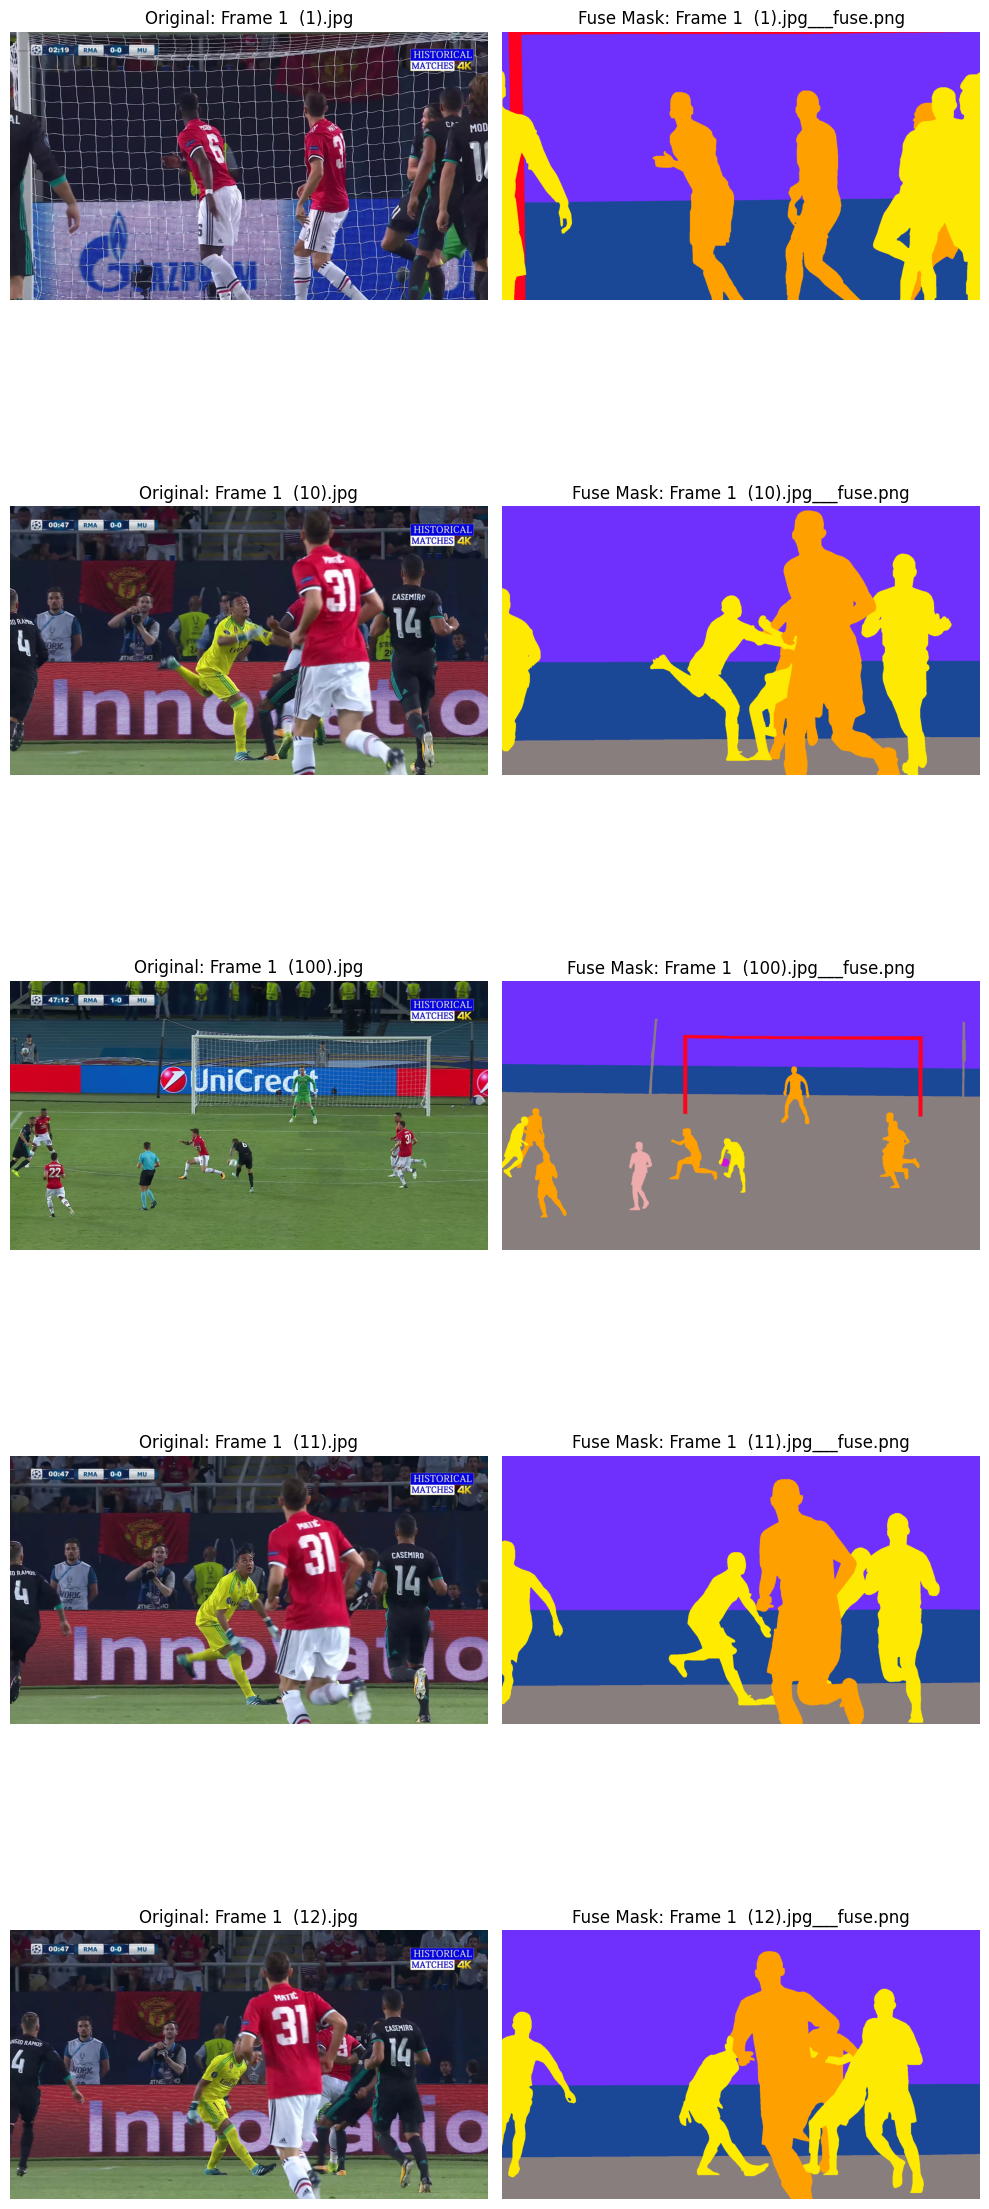

In [21]:
# ============================================
# 매칭 결과 시각화
# ============================================

sample_image_pairs = []
num_samples = 5

for orig_file in original_files[:num_samples]:
    base_name = orig_file.replace(".jpg", "")
    fuse_file = next((f for f in fuse_files if base_name in f), None)

    if fuse_file:
        sample_image_pairs.append((orig_file, fuse_file))

# 이미지 5쌍 시각화
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))

for i, (orig_file, fuse_file) in enumerate(sample_image_pairs):
    # 이미지 로드
    orig_img = cv2.imread(os.path.join(image_folder, orig_file))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # OpenCV BGR → RGB 변환

    fuse_img = cv2.imread(os.path.join(image_folder, fuse_file))
    fuse_img = cv2.cvtColor(fuse_img, cv2.COLOR_BGR2RGB)  # 마스크도 RGB 변환

    # 시각화
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original: {orig_file}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(fuse_img)
    axes[i, 1].set_title(f"Fuse Mask: {fuse_file}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# Transform 정의 (Albumentations)
# ============================================
import albumentations as A
# Transform 정의
train_transform = A.Compose([
    # 기하학적 변환 (이미지 + 마스크 동시)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit = 0.1,
        rotate_limit= 10,
        p=0.3
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10,
        p=0.3
    ),
])

test_transform  = None # 증강 없음

C:\Users\w00sh\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [23]:
# ============================================
# Dataset 생성
# ============================================

# 증강 적용
train_full_dataset = FootballDataset(
    image_files=original_files,
    mask_files= fuse_files,
    image_folder=image_folder,
    color_to_label=color_to_label,
    transform=train_transform,
    target_size=(256,256),
    verify_mapping=True,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

# 증강없음
test_full_dataset = FootballDataset(
    image_files=original_files,
    mask_files=fuse_files,
    image_folder=image_folder,
    color_to_label=color_to_label,
    transform=test_transform,
    target_size=(256, 256),
    verify_mapping=False,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

In [24]:
# ============================================
# Train/Test 분할
# ============================================
import random 

torch.manual_seed(42)
random.seed(42)

total_size = len(original_files)
indices = list(range(total_size))
random.shuffle(indices)

train_size = int(0.8 * total_size)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

from torch.utils.data import Subset
train_dataset = Subset(train_full_dataset, train_indices)
test_dataset = Subset(test_full_dataset, test_indices)

In [25]:
# ============================================
# DataLoader 생성
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True,
    num_workers=0,pin_memory=True
    )
test_loader = DataLoader(
    test_dataset, batch_size=8, shuffle=False,
    num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Train Batches: {len(train_loader)}, Test Batches: {len(test_loader)}")

Train: 80, Test: 20
Train Batches: 10, Test Batches: 3


In [26]:
# ============================================
# 모델 생성 및 확인
# ============================================

# 클래스 개수 확인
num_classes = len(color_to_label)
print(f"클래스 개수: {num_classes}")

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
    activation=None,
).to(device)

print(f"사용 디바이스: {device}")
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 모델 테스트 (dummy input)
dummy_input = torch.randn(1, 3, 256, 256).to(device)
with torch.no_grad():
    output = model(dummy_input)
    print(f"입력 shape: {dummy_input.shape}")
    print(f"출력 shape: {output.shape}")  # (1, num_classes, 256, 256)

클래스 개수: 11
사용 디바이스: cuda
모델 파라미터 수: 32,522,555
입력 shape: torch.Size([1, 3, 256, 256])
출력 shape: torch.Size([1, 11, 256, 256])


In [27]:
# 가중치 계산
class_weights = calculate_class_weights(train_loader, num_classes, device)
print("클래스 가중치:", class_weights)

클래스 가중치: tensor([0.1621, 0.0442, 0.0288, 0.0180, 5.9844, 2.0525, 0.0940, 0.5291, 1.4214,
        0.0806, 0.5849], device='cuda:0')


In [28]:
# ============================================
# 마스크 분석: 실제 사용되는 클래스 확인
# ============================================

print("마스크 분석 시작...")

# 모든 마스크에서 실제 사용되는 라벨 확인
all_labels = set()

for images, masks in train_loader:
    unique_labels = torch.unique(masks).cpu().numpy()
    all_labels.update(unique_labels)

print(f"\n실제 데이터에 존재하는 클래스: {sorted(all_labels)}")
print(f"총 {len(all_labels)}개 클래스 발견")

# 클래스별 픽셀 수 상세 분석
class_pixel_counts = torch.zeros(num_classes)

for images, masks in train_loader:
    for c in range(num_classes):
        class_pixel_counts[c] += (masks == c).sum().item()

print("\n클래스별 픽셀 수:")
for c in range(num_classes):
    if class_pixel_counts[c] > 0:
        print(f"  Class {c}: {class_pixel_counts[c]:,.0f} pixels")
    else:
        print(f"  Class {c}: 0 pixels")

마스크 분석 시작...

실제 데이터에 존재하는 클래스: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
총 11개 클래스 발견

클래스별 픽셀 수:
  Class 0: 279,450 pixels
  Class 1: 800,733 pixels
  Class 2: 1,240,059 pixels
  Class 3: 1,935,042 pixels
  Class 4: 5,699 pixels
  Class 5: 17,597 pixels
  Class 6: 380,557 pixels
  Class 7: 67,790 pixels
  Class 8: 24,872 pixels
  Class 9: 431,858 pixels
  Class 10: 59,223 pixels


In [29]:
# ============================================
# Dataset의 변환 과정 직접 확인
# ============================================

print("\nDataset 변환 과정 테스트...")

# 첫 번째 샘플 가져오기
test_dataset = FootballDataset(
    image_files=original_files[:1],
    mask_files=fuse_files[:1],
    image_folder=image_folder,
    color_to_label=color_to_label,
    transform=None,
    target_size=(256, 256),
    verify_mapping=False,
    mean=(0.485, 0.456, 0.406), 
    std=(0.229, 0.224, 0.225), 
)

# 원본 마스크 로드
mask_path = os.path.join(image_folder, fuse_files[0])
original_mask = cv2.imread(mask_path)
original_mask = cv2.cvtColor(original_mask, cv2.COLOR_BGR2RGB)
original_mask = cv2.resize(original_mask, (256, 256), interpolation=cv2.INTER_NEAREST)

print(f"\n원본 마스크 고유 색상: {len(np.unique(original_mask.reshape(-1, 3), axis=0))}개")

# Dataset에서 변환된 마스크 가져오기
_, converted_mask = test_dataset[0]
converted_mask_np = converted_mask.numpy()

print(f"변환된 마스크 고유 라벨: {np.unique(converted_mask_np)}")

# 각 라벨의 픽셀 수
for label in np.unique(converted_mask_np):
    count = np.sum(converted_mask_np == label)
    print(f"  라벨 {label}: {count:,} pixels")


Dataset 변환 과정 테스트...

원본 마스크 고유 색상: 6개
변환된 마스크 고유 라벨: [1 2 6 7 8 9]
  라벨 1: 15,392 pixels
  라벨 2: 30,354 pixels
  라벨 6: 9,957 pixels
  라벨 7: 1,712 pixels
  라벨 8: 543 pixels
  라벨 9: 7,578 pixels


In [30]:
# ============================================
# LUT 매핑 테스트
# ============================================

print("\nLUT 매핑 테스트...")

# 원본 마스크의 첫 번째 픽셀 10개 테스트
sample_mask_path = os.path.join(image_folder, fuse_files[0])
sample_mask = cv2.imread(sample_mask_path)
sample_mask = cv2.cvtColor(sample_mask, cv2.COLOR_BGR2RGB)
sample_mask = cv2.resize(sample_mask, (256, 256), interpolation=cv2.INTER_NEAREST)

# 샘플 픽셀들
sample_pixels = sample_mask[:10, :10].reshape(-1, 3)

print("\n샘플 픽셀 10개의 RGB → 라벨 변환:")
for i, pixel in enumerate(sample_pixels[:10]):
    rgb = tuple(int(c) for c in pixel)
    
    # LUT 사용한 변환
    key = (pixel[0] << 16) | (pixel[1] << 8) | pixel[2]
    label_from_lut = test_dataset.LUT[key] if hasattr(test_dataset, 'LUT') else -999
    
    # 직접 매핑 확인
    label_from_dict = color_to_label.get(rgb, -1)
    
    print(f"  픽셀 {i}: RGB {rgb}")
    print(f"    → LUT: {label_from_lut}")
    print(f"    → Dict: {label_from_dict}")


LUT 매핑 테스트...

샘플 픽셀 10개의 RGB → 라벨 변환:
  픽셀 0: RGB (111, 48, 253)
    → LUT: -1
    → Dict: 2
  픽셀 1: RGB (111, 48, 253)
    → LUT: -1
    → Dict: 2
  픽셀 2: RGB (111, 48, 253)
    → LUT: -1
    → Dict: 2
  픽셀 3: RGB (111, 48, 253)
    → LUT: -1
    → Dict: 2
  픽셀 4: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7
  픽셀 5: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7
  픽셀 6: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7
  픽셀 7: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7
  픽셀 8: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7
  픽셀 9: RGB (255, 0, 29)
    → LUT: -1
    → Dict: 7


문제는 Class 4 의 가중치가 너무 큽니다.

클래스 불균형이 심한것으로 보입니다.

In [31]:
# ============================================
# 클래스별 픽셀 수 상세 확인
# ============================================

class_pixel_counts = torch.zeros(num_classes)

print("클래스별 픽셀 수 계산 중...")
for _, masks in tqdm(train_loader, desc="Counting"):
    for c in range(num_classes):
        class_pixel_counts[c] += (masks == c).sum().item()

total_pixels = class_pixel_counts.sum()

print("\n클래스별 픽셀 수 및 비율:")
print("="*60)
for c in range(num_classes):
    count = class_pixel_counts[c].item()
    percentage = (count / total_pixels) * 100
    weight = class_weights[c].item()
    print(f"Class {c}: {count:>10,.0f} pixels ({percentage:>5.2f}%) | weight: {weight:.4f}")
print("="*60)
print(f"Total:   {total_pixels:>10,.0f} pixels (100.00%)")

클래스별 픽셀 수 계산 중...


Counting: 100%|██████████| 10/10 [00:02<00:00,  4.74it/s]


클래스별 픽셀 수 및 비율:
Class 0:    197,407 pixels ( 3.77%) | weight: 0.1621
Class 1:    809,767 pixels (15.45%) | weight: 0.0442
Class 2:  1,273,565 pixels (24.29%) | weight: 0.0288
Class 3:  1,973,715 pixels (37.65%) | weight: 0.0180
Class 4:      6,170 pixels ( 0.12%) | weight: 5.9844
Class 5:     17,623 pixels ( 0.34%) | weight: 2.0525
Class 6:    374,711 pixels ( 7.15%) | weight: 0.0940
Class 7:     65,978 pixels ( 1.26%) | weight: 0.5291
Class 8:     23,711 pixels ( 0.45%) | weight: 1.4214
Class 9:    438,810 pixels ( 8.37%) | weight: 0.0806
Class 10:     61,423 pixels ( 1.17%) | weight: 0.5849
Total:    5,242,880 pixels (100.00%)


class 4, class 5 클래스의 IoU가 너무 낮습니다.

일단 돌려보고 확인하겠습니다.

In [32]:
# ============================================
# 학습 시작
# ============================================

# 학습 실행
trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    num_classes=num_classes,
    device=device,
    num_epochs=50,
    lr=0.001,
    patience=7,
    model_name='football_resnet50_unet',
    class_weights=class_weights
)

print("\n학습 완료!")

d:\jupyter\Anaconda\install\envs\part2\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.75it/s]


Train Loss: 2.1023 | mIoU: 0.1178 | Pixel Acc: 0.2975
Val   Loss: 3.8469 | mIoU: 0.0195 | Pixel Acc: 0.1021
Validation mIoU increased (0.0195). Saving model...

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  4.57it/s]


...

Train Loss: 0.1881 | mIoU: 0.6893 | Pixel Acc: 0.9195
Val   Loss: 0.2080 | mIoU: 0.6292 | Pixel Acc: 0.9343
Early Stopping counter: 5/7

Epoch 41/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  4.74it/s]


Train Loss: 0.1905 | mIoU: 0.6898 | Pixel Acc: 0.9207
Val   Loss: 0.2108 | mIoU: 0.6298 | Pixel Acc: 0.9335
Early Stopping counter: 6/7

Epoch 42/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  4.82it/s]
C:\Users\w00sh\AppData\Local\Temp\ipykernel_28968\711161679.py:218: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m

Train Loss: 0.1979 | mIoU: 0.6810 | Pixel Acc: 0.9132
Val   Loss: 0.2111 | mIoU: 0.6308 | Pixel Acc: 0.9333
Early Stopping counter: 7/7
Early Stopping at epoch 42

총 학습 시간: 3.54분
최고 성능 모델 로드 완료

학습 완료!


#### 학습 시작 혹은 모델 불러오기

In [34]:
# ============================================
# 모델 불러오기
# ============================================

# 전체 파이프라인 설정
model, device, color_to_label, test_loader, label_to_color = setup_inference_pipeline(
    data_path='./data/images',  # 데이터 경로 수정
    color_mapping_path='color_mapping.json',
    model_path='football_resnet50_unet_best.pt'  # 저장한 모델 파일명
)

print("\n추론 준비 완료! 이제 검증 및 시각화를 진행할 수 있습니다.")

추론 파이프라인 설정 시작

1. 색상 매핑 로드...
'color_mapping.json'에서 11개의 색상 매핑을 불러왔습니다.

2. 모델 로드...
모델 로드 완료: football_resnet50_unet_best.pt
디바이스: cuda
클래스 개수: 11

3. 데이터 로드...
   원본 이미지: 100개
   마스크 이미지: 100개

4. Dataset 생성...
   테스트 데이터: 100개
   배치 수: 25개

파이프라인 설정 완료!

추론 준비 완료! 이제 검증 및 시각화를 진행할 수 있습니다.



모델 성능 평가 및 시각화 시작

학습 곡선 시각화...
학습 곡선이 'training_curves.png'에 저장되었습니다.


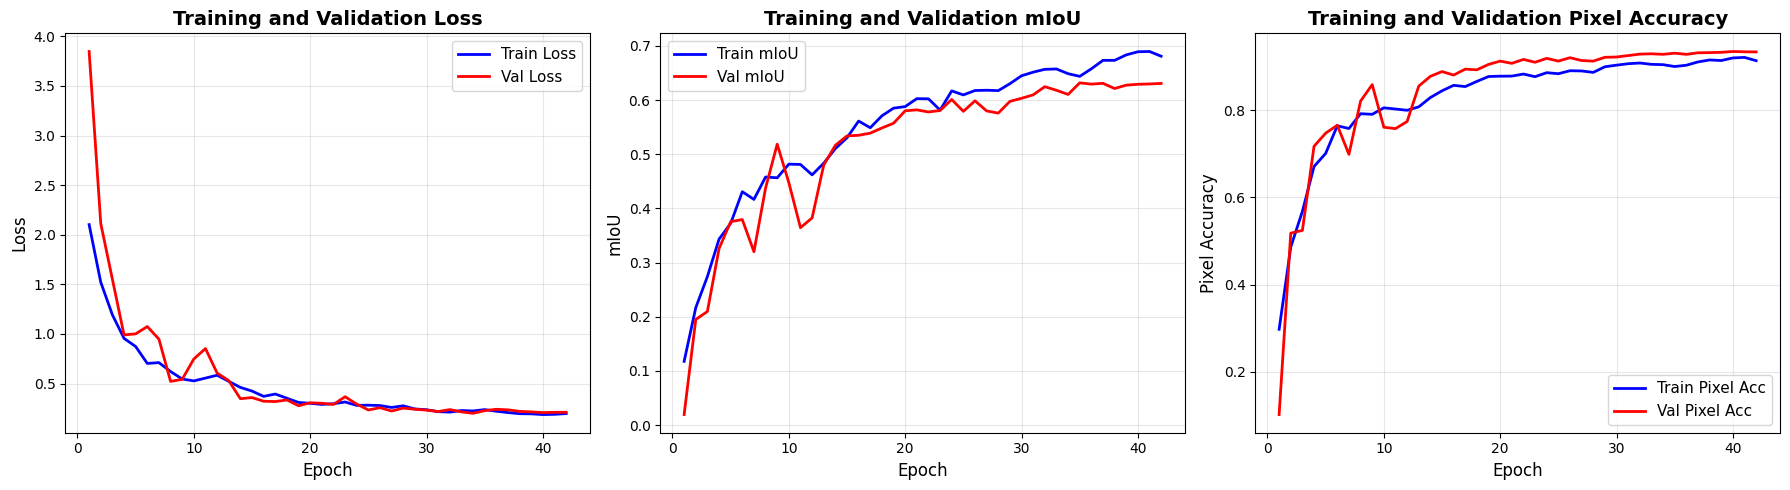


모델 성능 평가...
모델 평가 중...


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  6.69it/s]



전체 성능:
Pixel Accuracy: 0.9286
Mean IoU (mIoU): 0.6340
Dice Score: 0.7363

클래스별 성능 시각화...
클래스별 성능이 'class_performance.png'에 저장되었습니다.


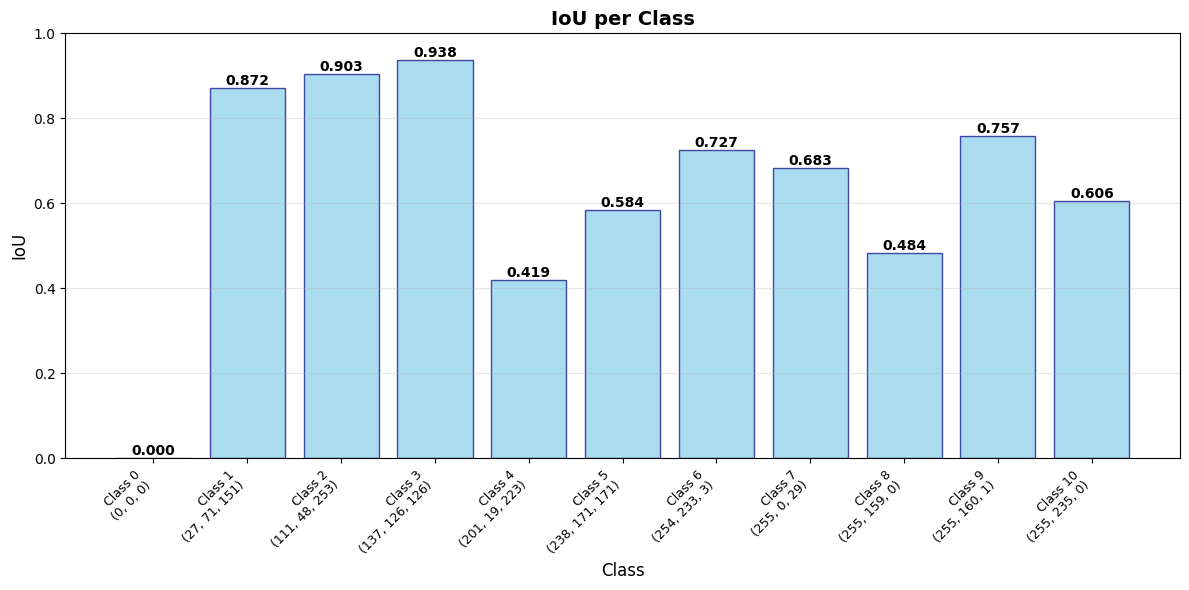


클래스별 IoU:
Class 0 (0, 0, 0): 0.0000
Class 1 (27, 71, 151): 0.8725
Class 2 (111, 48, 253): 0.9033
Class 3 (137, 126, 126): 0.9379
Class 4 (201, 19, 223): 0.4185
Class 5 (238, 171, 171): 0.5843
Class 6 (254, 233, 3): 0.7265
Class 7 (255, 0, 29): 0.6834
Class 8 (255, 159, 0): 0.4841
Class 9 (255, 160, 1): 0.7573
Class 10 (255, 235, 0): 0.6058

예측 결과 시각화...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


예측 결과가 'predictions.png'에 저장되었습니다.


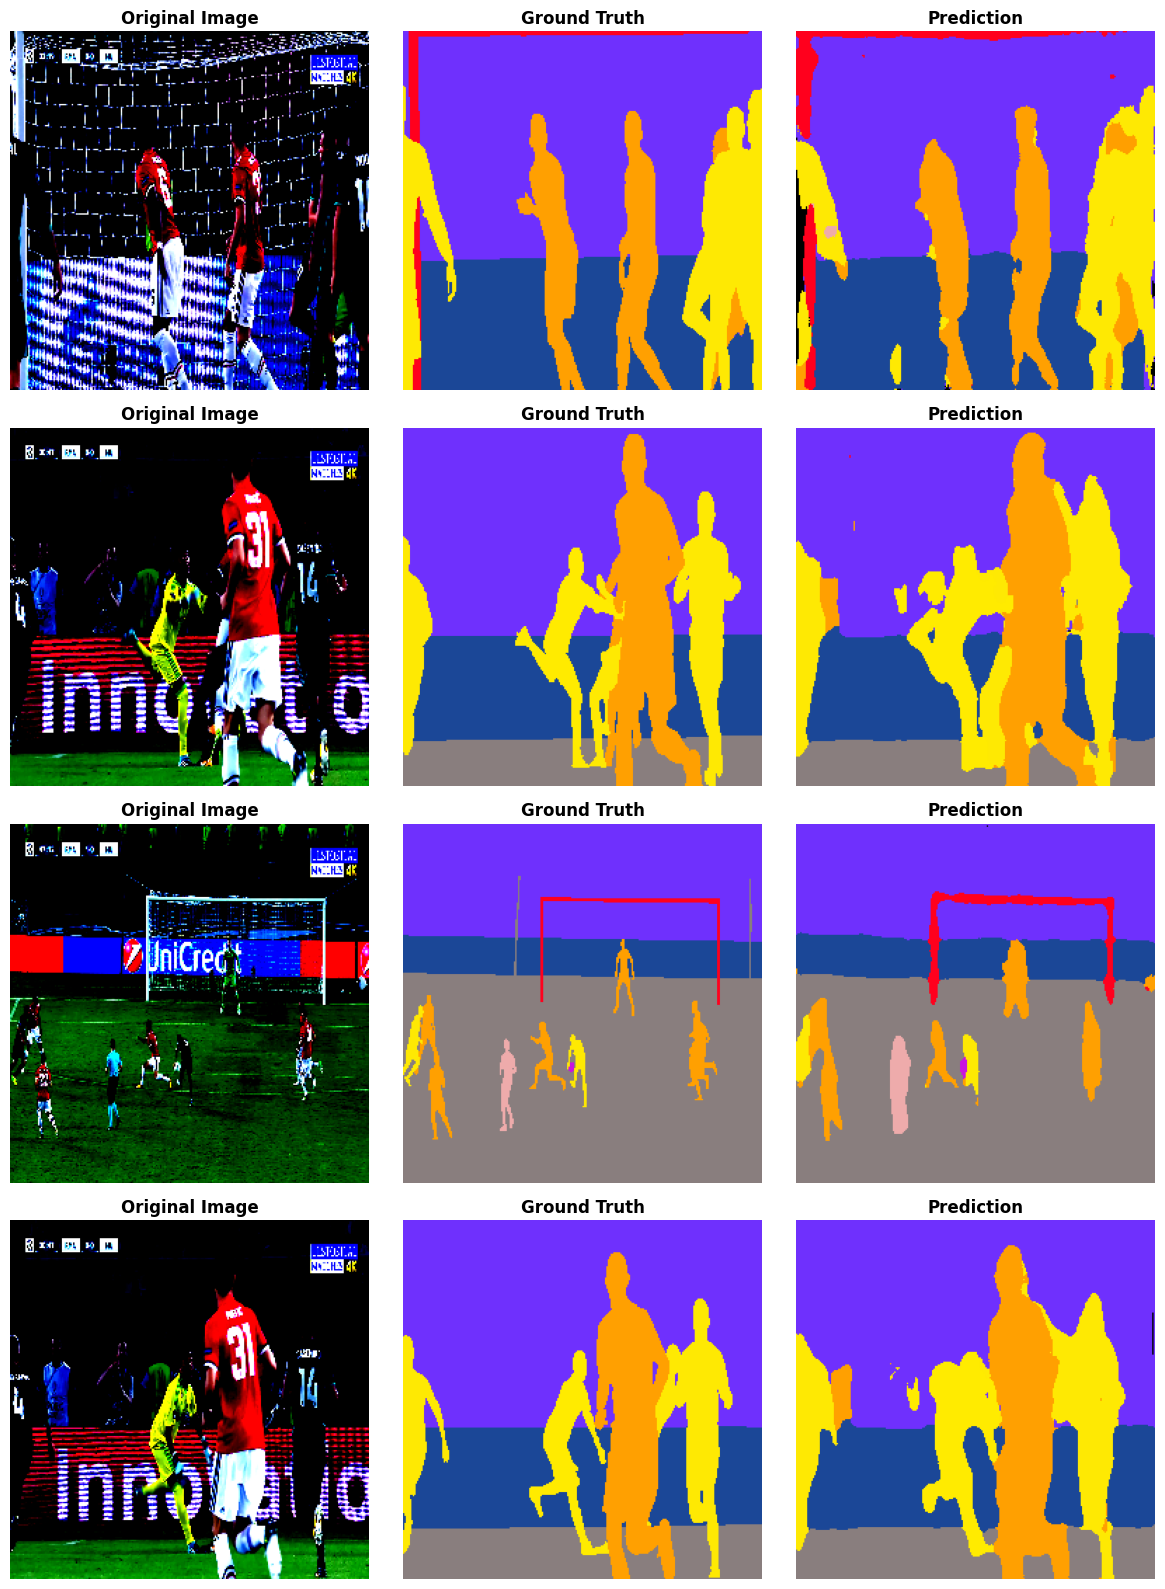


오버레이 시각화...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


오버레이 결과가 'overlay.png'에 저장되었습니다.


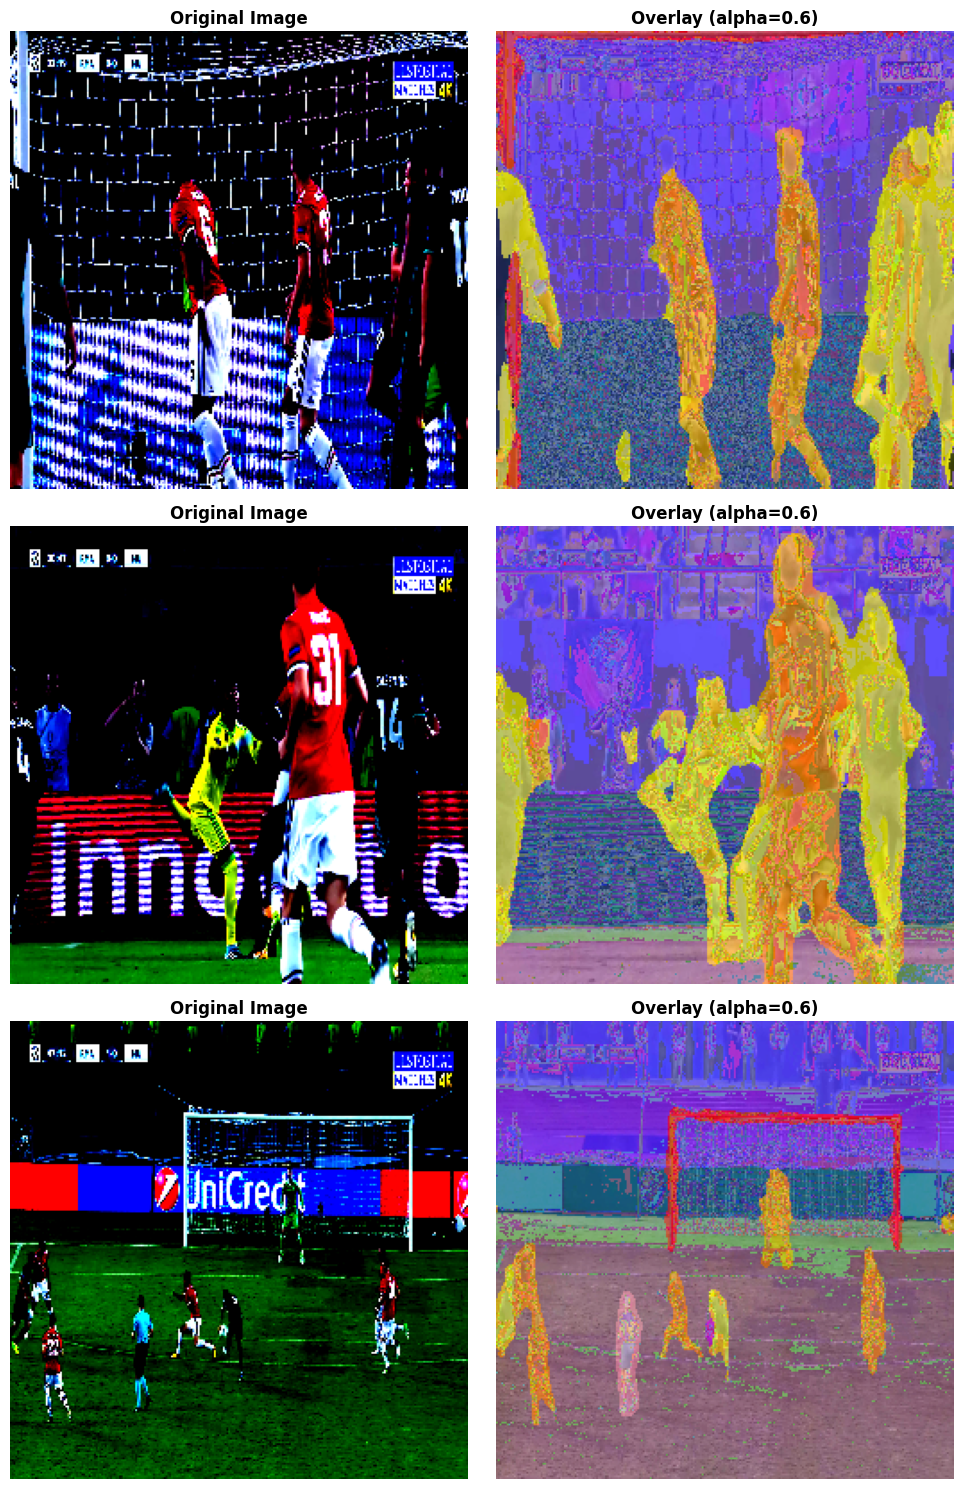


검증 및 시각화 완료!


In [35]:
# ============================================
# 학습 곡선 및 성능 평가
# ============================================

print("\n" + "="*60)
print("모델 성능 평가 및 시각화 시작")
print("="*60)

# 1. 학습 곡선 시각화 (history가 있는 경우)
if 'history' in locals():
    print("\n학습 곡선 시각화...")
    plot_training_curves(history, save_path='training_curves.png')
else:
    print("\n경고: history 객체가 없습니다. 학습 곡선을 건너뜁니다.")

# 2. 성능 평가
print("\n모델 성능 평가...")
num_classes = len(color_to_label)
metrics = evaluate_model(model, test_loader, device, num_classes)

print("\n전체 성능:")
print("="*40)
print(f"Pixel Accuracy: {metrics['pixel_accuracy']:.4f}")
print(f"Mean IoU (mIoU): {metrics['miou']:.4f}")
print(f"Dice Score: {metrics['dice']:.4f}")
print("="*40)

# 3. 클래스별 성능 시각화
print("\n클래스별 성능 시각화...")
plot_class_performance(metrics, color_to_label, save_path='class_performance.png')

# 4. 예측 결과 시각화 (5개 샘플)
print("\n예측 결과 시각화...")
visualize_predictions(model, test_loader, device, label_to_color, num_samples=4, save_path='predictions.png')

# 5. 오버레이 시각화 (3개 샘플)
print("\n오버레이 시각화...")
visualize_overlay(model, test_loader, device, label_to_color, num_samples=3, alpha=0.6, save_path='overlay.png')

print("\n" + "="*60)
print("검증 및 시각화 완료!")
print("="*60)

## 결론

U-Net 으로 세그멘테이션을 진행하였습니다.
## 결론 및 회고

### 성과 요약

| 항목 | 기존 커스텀 U-Net | ResNet50 U-Net | 향상 |
|------|-----------------|----------------|------|
| mIoU | 0.4553 | 0.6340 | +39% |
| Pixel Accuracy | 0.8539 | 0.9286 | +8.7% |

### 잘 된 점
- ResNet50 ImageNet 사전학습 가중치 덕분에 커스텀 U-Net 대비 mIoU 39% 향상
- 클래스 불균형(Class 4: 0.12%)에도 class_weights 적용으로 IoU 0.42 달성
- albumentations 기반 데이터 증강으로 일반화 성능 개선

### 아쉬운 점
- Class 0(배경) IoU 0.00 — 색상 매핑 누락으로 메트릭 미반영
- 데이터 100장으로 희귀 클래스(공, 심판) 학습 데이터 부족
- 256×256 해상도 제한으로 작은 객체(공) 세부 표현 한계

### 배운 점
- 사전학습 백본의 중요성: 랜덤 초기화 vs ImageNet 사전학습의 성능 차이 체감
- 클래스 불균형 처리: class_weights, Focal Loss의 역할 이해
- LUT(Lookup Table) 기반 빠른 RGB→라벨 변환 기법

### 개선 방향
- QAT(Quantization-Aware Training)로 모델 경량화 진행
- 데이터 추가 수집 또는 Mosaic 증강으로 희귀 클래스 보완
- 입력 해상도 512×512로 상향 검토
